# Notebook 2: Synthetic Data Generation and Quality Evaluation

## Project: Beyond Distributional Similarity — Evaluating Predictive Utility of Synthetic Liver Cirrhosis Data

**Dataset:** Mayo Clinic Primary Biliary Cirrhosis (PBC) Trial  
**Author:** Michael Udousoro

---

## What this notebook covers

With the preprocessed training data in hand from Notebook 1, we now train three generative models and evaluate the quality of the data they produce. The evaluation has two components: distributional fidelity (does the synthetic data look like the real data statistically?) and outlier analysis (are any synthetic records physiologically implausible?).

The three models are trained from scratch using TensorFlow:

- **Vanilla GAN** — a standard generative adversarial network that learns the overall patient distribution without any conditioning
- **CTGAN** — a conditional GAN that generates patients conditioned on their outcome label, helping to preserve the class balance
- **TVAE** — a tabular variational autoencoder that learns a compressed latent representation of the patient data

After generation, each dataset is cleaned using IQR-based filtering. A consensus set is then built from the records that at least two of the three models agree are realistic.

---

## Prerequisites

Run Notebook 1 first. This notebook loads the training data that Notebook 1 saved to `output/data/`.

---

## Outputs saved by this notebook

- `output/data/synthetic_gan.csv`, `synthetic_ctgan.csv`, `synthetic_tvae.csv` — raw generated records  
- `output/data/filtered_gan.csv`, `filtered_ctgan.csv`, `filtered_tvae.csv` — records after IQR filtering  
- `output/data/consensus.csv` — high-confidence records endorsed by at least two methods  
- `output/results/fid_scores.csv` — Fréchet Inception Distance for each method  
- `output/results/iqr_filter_summary.csv` — retention rates after filtering  
- `output/results/consensus_summary.csv` — contribution from each method to the consensus set  
- `output/results/stats_*.csv` — results from all five statistical tests  
- `output/figures/fig0` through `fig5` — training loss curves, FID comparison, IQR filtering, distributions, correlations, consensus

In [1]:
%matplotlib inline
import os
import sys
import pandas as pd
import numpy as np
import matplotlib

import matplotlib.pyplot as plt

sys.path.insert(0, os.getcwd())

from src.data_loader         import load_scaler, save_data, post_process_synthetic, ALL_FEATURE_COLS, TARGET_COL, CONTINUOUS_COLS
from src.synthetic_generator import VanillaGAN, CTGAN, TVAE, generate_synthetic
from src.iqr_filter          import filter_all, filter_summary_df
from src.consensus_voting    import run_consensus, consensus_summary_df
from src.fid_calculator      import compute_all_fids
from src.statistical_analysis import run_all_statistical_tests
from src.visualizations      import (
    plot_training_losses, plot_fid_comparison, plot_iqr_filtering,
    plot_distribution_comparison, plot_correlation_heatmap, plot_consensus_distribution
)

os.makedirs('output/data',    exist_ok=True)
os.makedirs('output/figures', exist_ok=True)
os.makedirs('output/results', exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


---

## Section 1: Loading Preprocessed Training Data

We load the training set and scaler that were saved by Notebook 1. The scaler is used to normalise the training data before feeding it to the generative models, and to convert generated samples back to the original measurement units afterwards.

In [2]:
train_df = pd.read_csv('output/data/train_real.csv')
scaler   = load_scaler()

col_order    = ALL_FEATURE_COLS + [TARGET_COL]
target_idx   = col_order.index(TARGET_COL)
X_train_scaled = scaler.transform(train_df[col_order])

print(f'Training set loaded: {len(train_df)} patients, {len(col_order)} features')
print(f'Target column index in feature array: {target_idx}')
print(f'Scaled data range: {X_train_scaled.min():.4f} to {X_train_scaled.max():.4f}')

Training set loaded: 193 patients, 19 features
Target column index in feature array: 18
Scaled data range: 0.0000 to 1.0000


---

## Section 2: Generation Settings

The settings below control how many synthetic records are generated and how long each model trains. For the full paper-quality run, use `N_SYNTHETIC = 500`, `EPOCHS_GAN = 500`, and `EPOCHS_CTGAN = EPOCHS_TVAE = 300`. For a quick test to verify the pipeline, set all epochs to 50 and samples to 200.

In [3]:
# Set these values for your run.
# Full paper-quality run: N_SYNTHETIC=500, EPOCHS_GAN=500, EPOCHS_CTGAN=300, EPOCHS_TVAE=300
# Quick verification run: N_SYNTHETIC=200, all epochs=50

N_SYNTHETIC  = 500   # number of synthetic records to generate per method
EPOCHS_GAN   = 500   # training epochs for Vanilla GAN
EPOCHS_CTGAN = 300   # training epochs for CTGAN
EPOCHS_TVAE  = 300   # training epochs for TVAE
PRINT_EVERY  = 100   # print training progress every this many epochs

print(f'Generation settings:')
print(f'  Synthetic records per method : {N_SYNTHETIC}')
print(f'  GAN epochs                   : {EPOCHS_GAN}')
print(f'  CTGAN epochs                 : {EPOCHS_CTGAN}')
print(f'  TVAE epochs                  : {EPOCHS_TVAE}')

Generation settings:
  Synthetic records per method : 500
  GAN epochs                   : 500
  CTGAN epochs                 : 300
  TVAE epochs                  : 300


---

## Section 3: Vanilla GAN

The Vanilla GAN consists of two neural networks trained in opposition. The generator takes a random noise vector of 100 dimensions and produces a synthetic patient record. The discriminator tries to tell apart real and generated records. Through this adversarial process, the generator is forced to produce records that are increasingly realistic.

Both networks use dense layers with LeakyReLU activations and batch normalisation. The generator's output layer uses sigmoid to constrain values to the scaled range. Binary cross-entropy is used as the loss function for both networks.

In [4]:
print(f'Training Vanilla GAN for {EPOCHS_GAN} epochs ...')

gan = VanillaGAN(
    latent_dim=100,
    epochs=EPOCHS_GAN,
    batch_size=32,
    lr=2e-4,
    print_every=PRINT_EVERY
)
gan.fit(X_train_scaled, verbose=True)

synthetic_gan = generate_synthetic(gan, N_SYNTHETIC, scaler, col_order, post_process_synthetic)
save_data(synthetic_gan, 'synthetic_gan.csv')
print(f'\nVanilla GAN generated {len(synthetic_gan)} synthetic records.')

Training Vanilla GAN for 500 epochs ...


  Vanilla GAN  epoch  100 of 500  generator loss 0.8312  discriminator loss 1.2763


  Vanilla GAN  epoch  200 of 500  generator loss 0.7792  discriminator loss 1.3260


  Vanilla GAN  epoch  300 of 500  generator loss 0.7264  discriminator loss 1.2994


  Vanilla GAN  epoch  400 of 500  generator loss 0.7346  discriminator loss 1.3226


  Vanilla GAN  epoch  500 of 500  generator loss 0.8039  discriminator loss 1.3955
Saved synthetic_gan.csv to /Users/michaeludousoro/Desktop/liver_cirrhosis_article/output/data/synthetic_gan.csv

Vanilla GAN generated 500 synthetic records.


---

## Section 4: Conditional GAN (CTGAN)

CTGAN addresses a key limitation of the Vanilla GAN for this dataset: class imbalance. In the training data, roughly 60 percent of patients survived and 40 percent died. A standard GAN would learn this imbalance and generate mostly survived-patient records.

CTGAN solves this by conditioning generation on the outcome label. During training, mini-batches are balanced 50/50 between the two classes regardless of their natural proportion. The generator takes both a noise vector and a one-hot encoded outcome label as input, allowing it to generate realistic patients of either class on demand.

In [5]:
print(f'Training CTGAN for {EPOCHS_CTGAN} epochs ...')

ctgan = CTGAN(
    latent_dim=100,
    epochs=EPOCHS_CTGAN,
    batch_size=32,
    lr=2e-4,
    n_classes=2,
    target_col_idx=target_idx,
    print_every=PRINT_EVERY
)
ctgan.fit(X_train_scaled, verbose=True)

synthetic_ctgan = generate_synthetic(ctgan, N_SYNTHETIC, scaler, col_order, post_process_synthetic)
save_data(synthetic_ctgan, 'synthetic_ctgan.csv')
print(f'\nCTGAN generated {len(synthetic_ctgan)} synthetic records.')

Training CTGAN for 300 epochs ...


  CTGAN  epoch  100 of 300  generator loss 0.7964  discriminator loss 1.2632


  CTGAN  epoch  200 of 300  generator loss 0.8218  discriminator loss 1.1886


  CTGAN  epoch  300 of 300  generator loss 0.8370  discriminator loss 1.2439
Saved synthetic_ctgan.csv to /Users/michaeludousoro/Desktop/liver_cirrhosis_article/output/data/synthetic_ctgan.csv

CTGAN generated 500 synthetic records.


---

## Section 5: Tabular Variational Autoencoder (TVAE)

TVAE takes a different approach from the GANs. Instead of adversarial training, it learns a compressed continuous representation of each patient in a 32-dimensional latent space. The encoder maps a real patient record to a distribution in latent space (parameterised by a mean and variance vector). The decoder maps a sampled point from that distribution back to a full patient record.

The loss function has two parts: a reconstruction term that penalises differences between the original and reconstructed record, and a KL divergence term that regularises the latent space to follow a standard normal distribution. This regularisation makes the latent space smooth and allows new patients to be generated by sampling random points from it.

In [6]:
print(f'Training TVAE for {EPOCHS_TVAE} epochs ...')

tvae = TVAE(
    latent_dim=32,
    epochs=EPOCHS_TVAE,
    batch_size=32,
    lr=1e-3,
    beta=1.0,
    print_every=PRINT_EVERY
)
tvae.fit(X_train_scaled, verbose=True)

synthetic_tvae = generate_synthetic(tvae, N_SYNTHETIC, scaler, col_order, post_process_synthetic)
save_data(synthetic_tvae, 'synthetic_tvae.csv')
print(f'\nTVAE generated {len(synthetic_tvae)} synthetic records.')

Training TVAE for 300 epochs ...


  TVAE  epoch  100 of 300  total loss 0.0864


  TVAE  epoch  200 of 300  total loss 0.0846


  TVAE  epoch  300 of 300  total loss 0.0781
Saved synthetic_tvae.csv to /Users/michaeludousoro/Desktop/liver_cirrhosis_article/output/data/synthetic_tvae.csv

TVAE generated 500 synthetic records.


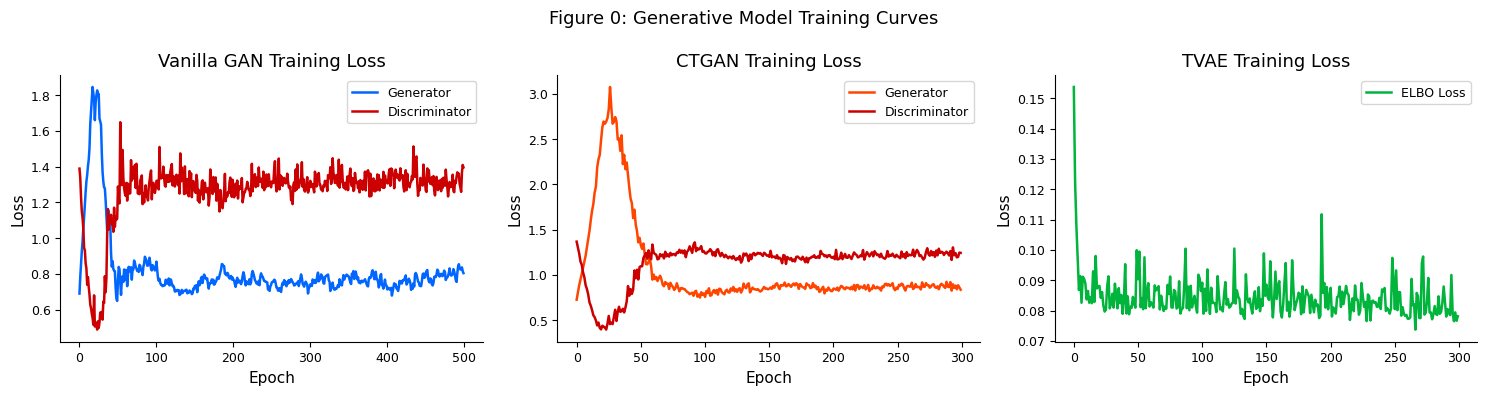

  Figure saved: /Users/michaeludousoro/Desktop/liver_cirrhosis_article/output/figures/fig0_training_losses.png
Figure 0 (training loss curves) saved.


In [7]:
# Visualise the training loss curves for all three models
plot_training_losses(gan, ctgan, tvae)
print('Figure 0 (training loss curves) saved.')
plt.show()

---

## Section 6: IQR-Based Outlier Filtering

Generative models can sometimes produce records with feature values that are outside the physiologically plausible range for this patient population. For example, a negative bilirubin level, or a prothrombin time ten times higher than any real patient. We remove these using the Tukey fence criterion.

For each continuous feature, we compute the interquartile range from the real training data and remove any synthetic record where that feature falls below Q1 minus 1.5 times the IQR, or above Q3 plus 1.5 times the IQR. The bounds come from the real data only — never from the synthetic data — because the real data defines what is clinically possible.

In [8]:
raw_synthetics = {'GAN': synthetic_gan, 'CTGAN': synthetic_ctgan, 'TVAE': synthetic_tvae}

iqr_result = filter_all(raw_synthetics, train_df)

filtered_gan   = iqr_result['filtered']['GAN']
filtered_ctgan = iqr_result['filtered']['CTGAN']
filtered_tvae  = iqr_result['filtered']['TVAE']

save_data(filtered_gan,   'filtered_gan.csv')
save_data(filtered_ctgan, 'filtered_ctgan.csv')
save_data(filtered_tvae,  'filtered_tvae.csv')

iqr_summary = filter_summary_df(iqr_result['retention'])
iqr_summary.to_csv('output/results/iqr_filter_summary.csv', index=False)

print('IQR filter results:')
print(iqr_summary.to_string(index=False))

  IQR filter    GAN: started with 500 records, kept 226 (45.2% retained)
  IQR filter  CTGAN: started with 500 records, kept 210 (42.0% retained)
  IQR filter   TVAE: started with 500 records, kept 500 (100.0% retained)
Saved filtered_gan.csv to /Users/michaeludousoro/Desktop/liver_cirrhosis_article/output/data/filtered_gan.csv
Saved filtered_ctgan.csv to /Users/michaeludousoro/Desktop/liver_cirrhosis_article/output/data/filtered_ctgan.csv
Saved filtered_tvae.csv to /Users/michaeludousoro/Desktop/liver_cirrhosis_article/output/data/filtered_tvae.csv
IQR filter results:
Method  Retention_Percent
   GAN               45.2
 CTGAN               42.0
  TVAE              100.0


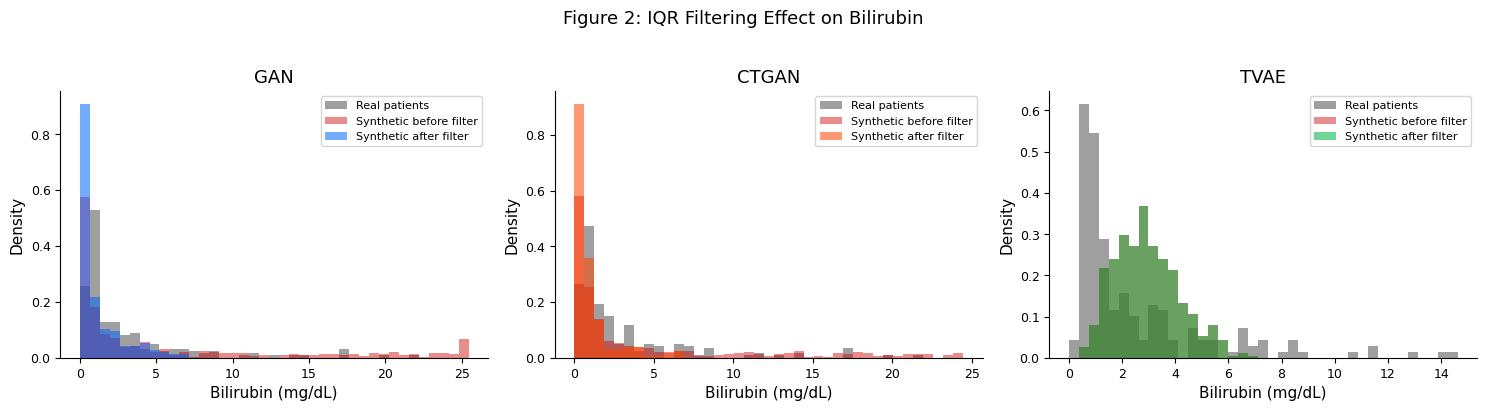

  Figure saved: /Users/michaeludousoro/Desktop/liver_cirrhosis_article/output/figures/fig2_iqr_filtering.png
Figure 2 (IQR filtering effect) saved.


In [9]:
plot_iqr_filtering(
    train_df, raw_synthetics,
    {'GAN': filtered_gan, 'CTGAN': filtered_ctgan, 'TVAE': filtered_tvae}
)
print('Figure 2 (IQR filtering effect) saved.')

---

## Section 7: Consensus Voting

The three filtered synthetic datasets represent three independent views of what realistic PBC patients look like. A record that all three models agree is plausible is more likely to genuinely reflect the real patient distribution than a record only one model produced.

We identify these high-confidence records through consensus voting. For each record from each method, we measure the shortest standardised Euclidean distance to any record from each of the other two methods. If a record is within the tolerance threshold of at least one record from each of the other two methods, it receives two votes and is accepted into the consensus set.

The tolerance parameter controls how strictly we define agreement between methods. A smaller tolerance means we only accept records where the methods are in very close agreement.

In [10]:
consensus_df, source_counts = run_consensus(
    filtered_gan, filtered_ctgan, filtered_tvae,
    tolerance=0.5, min_votes=2, verbose=True
)

# If no records pass the default tolerance, retry with progressively looser thresholds.
# This can happen when models are trained for fewer epochs.
for fallback_tolerance in [1.0, 2.0, 5.0]:
    if len(consensus_df) > 0:
        break
    print(f'No consensus at tolerance 0.5. Retrying at tolerance {fallback_tolerance} ...')
    consensus_df, source_counts = run_consensus(
        filtered_gan, filtered_ctgan, filtered_tvae,
        tolerance=fallback_tolerance, min_votes=2, verbose=True
    )

if len(consensus_df) == 0:
    print('No consensus found. Substituting filtered CTGAN as fallback.')
    consensus_df  = filtered_ctgan.copy()
    source_counts = {'CTGAN': len(filtered_ctgan), 'GAN': 0, 'TVAE': 0}

save_data(consensus_df, 'consensus.csv')

consensus_summary = consensus_summary_df(source_counts)
consensus_summary.to_csv('output/results/consensus_summary.csv', index=False)

print(f'\nConsensus set: {len(consensus_df)} records accepted')
print(consensus_summary.to_string(index=False))

  Consensus: evaluating 226 records from GAN against ['CTGAN', 'TVAE']
  Consensus: evaluating 210 records from CTGAN against ['GAN', 'TVAE']
  Consensus: evaluating 500 records from TVAE against ['GAN', 'CTGAN']
  Consensus: no records passed at tolerance 0.5.
No consensus at tolerance 0.5. Retrying at tolerance 1.0 ...
  Consensus: evaluating 226 records from GAN against ['CTGAN', 'TVAE']
  Consensus: evaluating 210 records from CTGAN against ['GAN', 'TVAE']
  Consensus: evaluating 500 records from TVAE against ['GAN', 'CTGAN']
  Consensus: no records passed at tolerance 1.0.
No consensus at tolerance 0.5. Retrying at tolerance 2.0 ...
  Consensus: evaluating 226 records from GAN against ['CTGAN', 'TVAE']
  Consensus: evaluating 210 records from CTGAN against ['GAN', 'TVAE']
  Consensus: evaluating 500 records from TVAE against ['GAN', 'CTGAN']
  Consensus: no records passed at tolerance 2.0.
No consensus at tolerance 0.5. Retrying at tolerance 5.0 ...
  Consensus: evaluating 226 rec

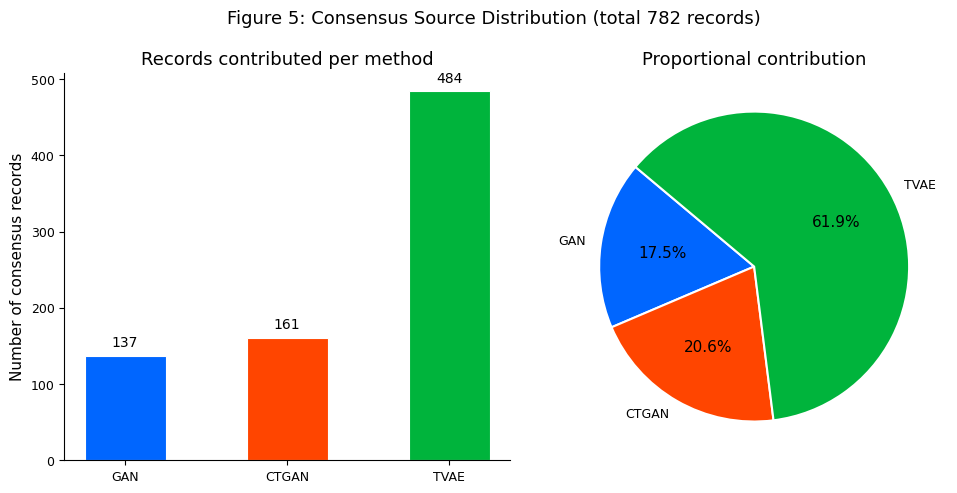

  Figure saved: /Users/michaeludousoro/Desktop/liver_cirrhosis_article/output/figures/fig5_consensus_distribution.png
Figure 5 (consensus source distribution) saved.


In [11]:
plot_consensus_distribution(source_counts)
print('Figure 5 (consensus source distribution) saved.')

---

## Section 8: Fréchet Inception Distance (FID)

The FID score measures how closely each synthetic dataset's distribution resembles the real training distribution. It compares both datasets by approximating each as a multivariate Gaussian and computing the Fréchet distance between them — a combination of the difference in means and the difference in covariance structure.

A lower FID score is better. A score of zero would mean the two distributions are statistically identical. The FID is computed on the 11 continuous clinical features after MinMax normalisation, so all features contribute equally regardless of their measurement units.

In [12]:
print('Computing FID scores (lower is better) ...')
print()

fid_df = compute_all_fids(train_df, filtered_gan, filtered_ctgan, filtered_tvae, consensus_df)
fid_df.to_csv('output/results/fid_scores.csv', index=False)

print()
print('FID summary:')
print(fid_df.to_string(index=False))

Computing FID scores (lower is better) ...

  FID for GAN (filtered)           : 0.0972  (n = 226)
  FID for CTGAN (filtered)         : 0.0751  (n = 210)
  FID for TVAE (filtered)          : 0.2194  (n = 500)
  FID for Consensus                : 0.1116  (n = 782)

FID summary:
          Method    FID  n_samples
  GAN (filtered) 0.0972        226
CTGAN (filtered) 0.0751        210
 TVAE (filtered) 0.2194        500
       Consensus 0.1116        782


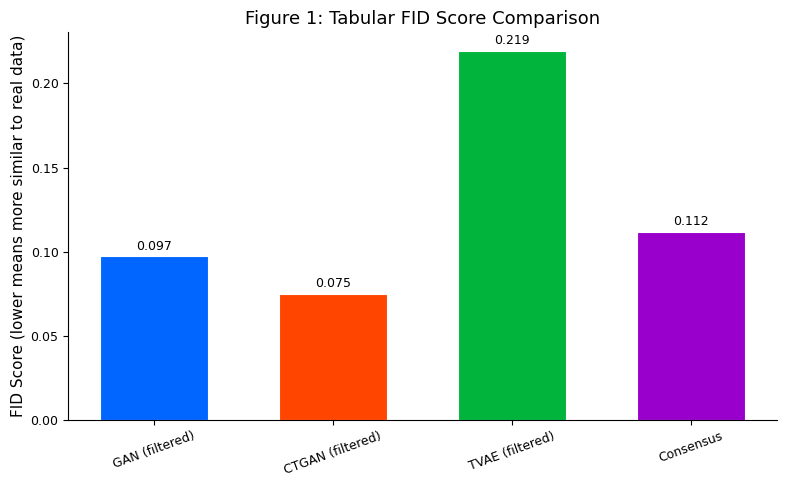

  Figure saved: /Users/michaeludousoro/Desktop/liver_cirrhosis_article/output/figures/fig1_fid_comparison.png
Figure 1 (FID comparison) saved.


In [13]:
plot_fid_comparison(fid_df)
print('Figure 1 (FID comparison) saved.')

---

## Section 9: Distribution Comparison and Correlation

Visual inspection of feature distributions and correlation structure confirms whether the synthetic datasets qualitatively resemble the real data in ways that the FID score alone does not capture.

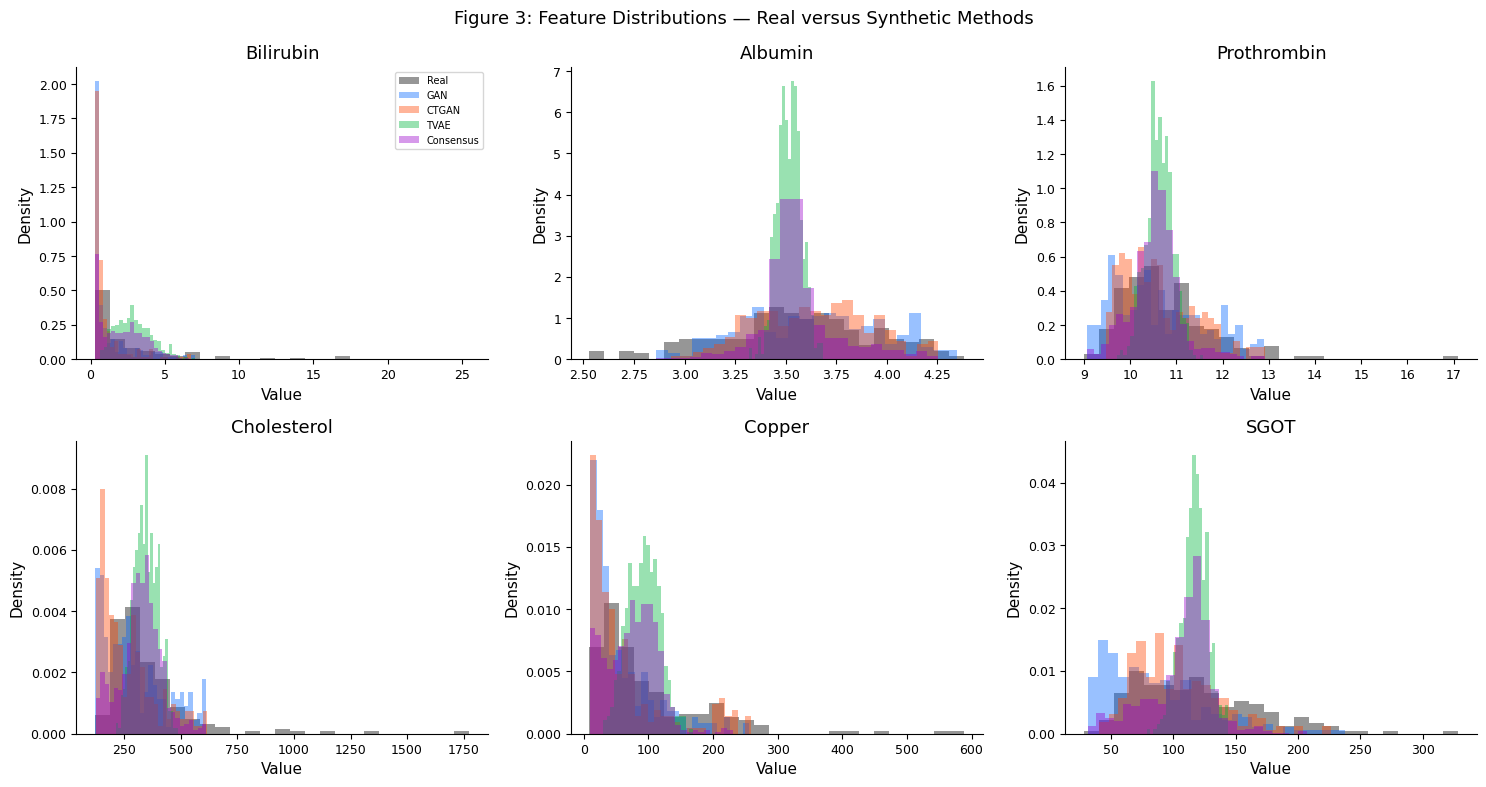

  Figure saved: /Users/michaeludousoro/Desktop/liver_cirrhosis_article/output/figures/fig3_distribution_comparison.png
Figure 3 (feature distribution comparison) saved.


In [14]:
plot_distribution_comparison(train_df, {
    'GAN':       filtered_gan,
    'CTGAN':     filtered_ctgan,
    'TVAE':      filtered_tvae,
    'Consensus': consensus_df,
})
print('Figure 3 (feature distribution comparison) saved.')
plt.show()

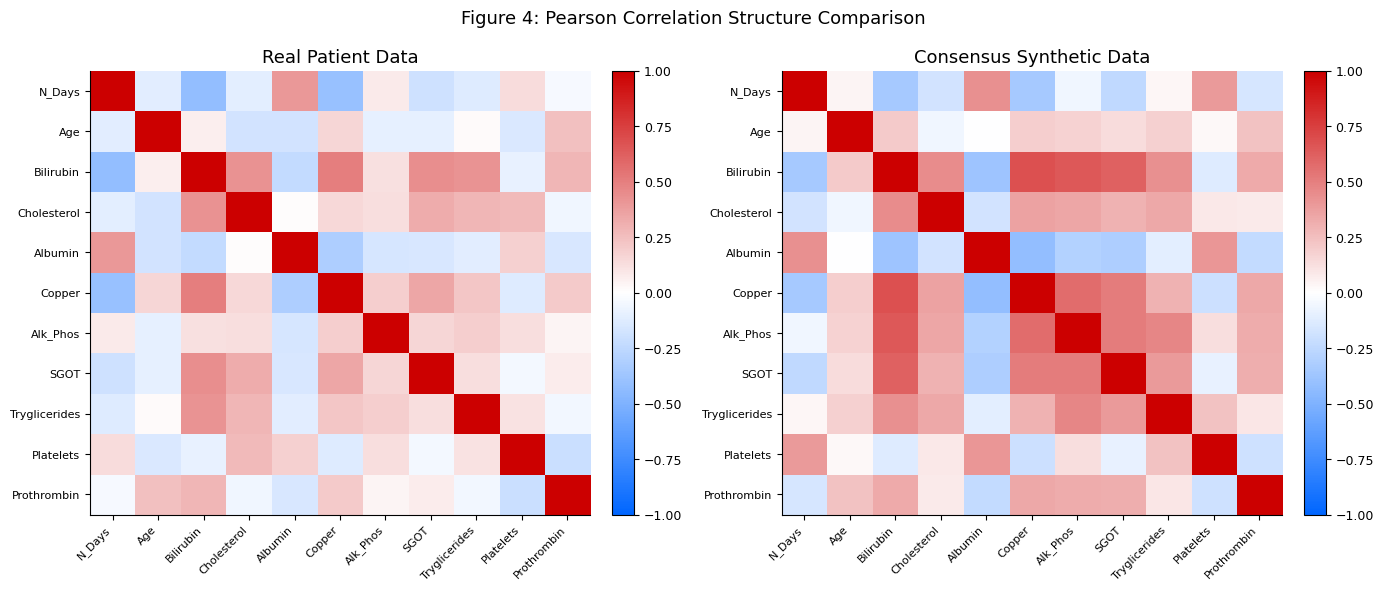

  Figure saved: /Users/michaeludousoro/Desktop/liver_cirrhosis_article/output/figures/fig4_correlation_heatmap.png
Figure 4 (correlation heatmap) saved.


In [15]:
plot_correlation_heatmap(train_df, consensus_df)
print('Figure 4 (correlation heatmap) saved.')

---

## Section 10: Formal Statistical Tests

Visual comparisons are subjective. We complement them with five formal statistical tests that provide reproducible, quantifiable evidence about the similarity between real and synthetic distributions.

**Shapiro-Wilk** tests whether each continuous feature in the real data is normally distributed. This is important because it tells us whether parametric tests (which assume normality) are appropriate.

**Kolmogorov-Smirnov** compares the full empirical distribution of each feature between real and synthetic data. A significant p-value (below 0.05) means the distributions differ significantly.

**Jensen-Shannon Divergence** gives a symmetric, bounded measure of how different two distributions are. The squared JSD ranges from 0 (identical) to 1 (completely non-overlapping).

**Cohen's d** measures the standardised mean difference — how large the difference in means is relative to the spread. This tells us whether a statistically significant difference is also practically meaningful.

**Chi-square** tests whether the proportions of each category in the synthetic data match those in the real data for binary and ordinal features.

In [16]:
synthetic_dict = {
    'GAN (filtered)':   filtered_gan,
    'CTGAN (filtered)': filtered_ctgan,
    'TVAE (filtered)':  filtered_tvae,
    'Consensus':        consensus_df,
}

statistical_results = run_all_statistical_tests(train_df, synthetic_dict)

for test_name, result_df in statistical_results.items():
    if len(result_df) > 0:
        result_df.to_csv(f'output/results/stats_{test_name}.csv', index=False)

print('\nAll statistical test results saved.')


  Running Shapiro-Wilk normality tests on real data features ...
  Running Kolmogorov-Smirnov distribution comparison tests ...
  Computing Jensen-Shannon divergences ...
  Computing Cohen's d effect sizes ...
  Running chi-square tests on categorical features ...

All statistical test results saved.


In [17]:
print('Shapiro-Wilk normality results for real data features:')
statistical_results['shapiro_wilk']

Shapiro-Wilk normality results for real data features:


,Feature,W_statistic,p_value,Normal
0,N_Days,0.9718,0.000628,No
1,Age,0.9907,0.251068,Yes
2,Bilirubin,0.6361,0.000000,No
3,Cholesterol,0.6762,0.000000,No
4,Albumin,0.9899,0.194078,Yes
5,Copper,0.7683,0.000000,No
6,Alk_Phos,0.5909,0.000000,No
7,SGOT,0.9482,0.000002,No
8,Tryglicerides,0.7989,0.000000,No
9,Platelets,0.9873,0.082422,Yes


In [18]:
print('KS test results (significant rows shown):')
ks = statistical_results['ks_tests']
ks[ks['Significant_difference'] == 'Yes']

KS test results (significant rows shown):


,Method,Feature,KS_stat,p_value,Significant_difference
2,GAN (filtered),Bilirubin,0.4679,0.000000,Yes
3,GAN (filtered),Cholesterol,0.2546,0.000002,Yes
5,GAN (filtered),Copper,0.3069,0.000000,Yes
6,GAN (filtered),Alk_Phos,0.6879,0.000000,Yes
7,GAN (filtered),SGOT,0.3250,0.000000,Yes
8,GAN (filtered),Tryglicerides,0.1790,0.002123,Yes
9,GAN (filtered),Platelets,0.1436,0.023980,Yes
10,GAN (filtered),Prothrombin,0.1722,0.003514,Yes
13,CTGAN (filtered),Bilirubin,0.4444,0.000000,Yes
14,CTGAN (filtered),Cholesterol,0.3665,0.000000,Yes


In [19]:
print('Cohen d effect sizes (large effects shown):')
cd = statistical_results['cohens_d']
cd[cd['Effect_size'].isin(['large', 'medium'])]

Cohen d effect sizes (large effects shown):


,Method,Feature,Cohen_d,Effect_size
2,GAN (filtered),Bilirubin,0.6277,medium
5,GAN (filtered),Copper,0.5644,medium
6,GAN (filtered),Alk_Phos,0.9219,large
7,GAN (filtered),SGOT,0.7394,medium
13,CTGAN (filtered),Bilirubin,0.6866,medium
14,CTGAN (filtered),Cholesterol,0.5699,medium
17,CTGAN (filtered),Alk_Phos,0.5839,medium


In [20]:
print('\nNotebook 2 complete.')
print('All generation and quality evaluation outputs have been saved.')


Notebook 2 complete.
All generation and quality evaluation outputs have been saved.


---

## Section 11: t-SNE Visualisation — Real versus Synthetic in 2D

t-SNE (t-distributed Stochastic Neighbour Embedding) compresses the full 18-dimensional patient feature space down to two dimensions while preserving local neighbourhood structure. When we plot real and synthetic patients together in this 2D space, we can visually assess whether the synthetic records occupy the same regions as real patients or drift into areas the real data never covers.

A good generative model produces synthetic points that are interleaved with real points — not clustered separately in a corner of the map. Separation between real and synthetic clusters would indicate the model has failed to learn the real distribution.

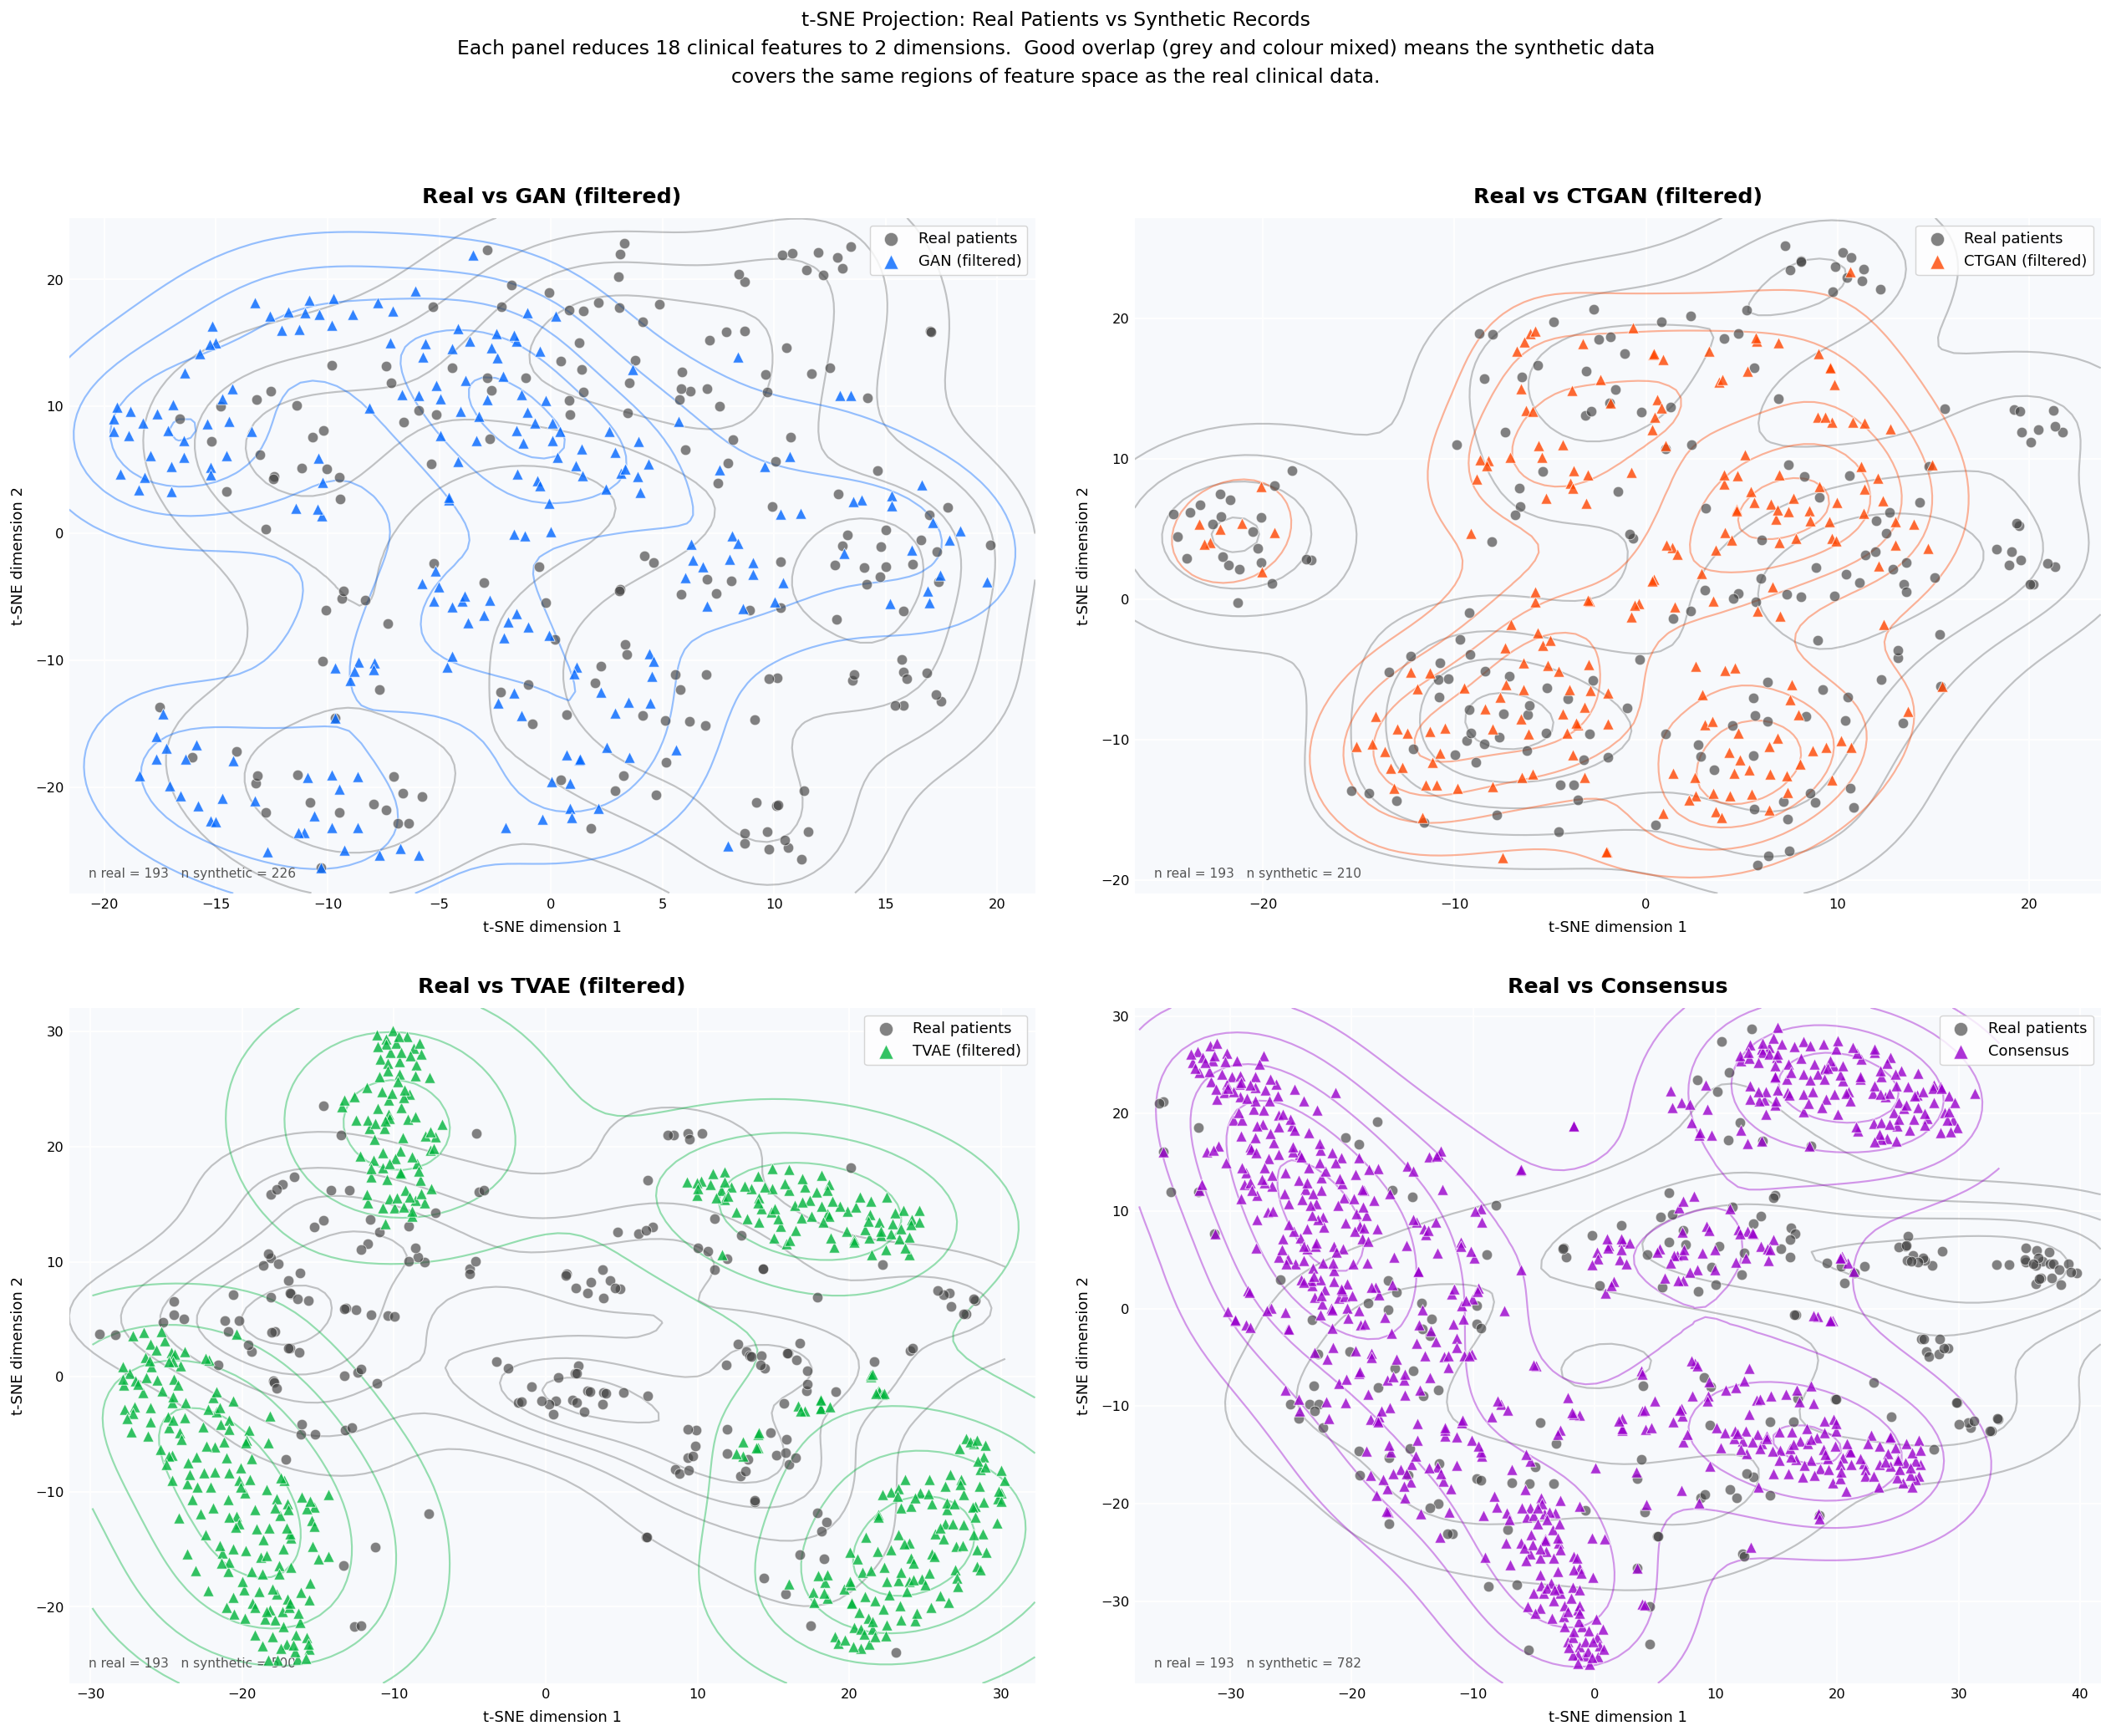

t-SNE figure saved.


In [21]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import os, sys
sys.path.insert(0, os.getcwd())
from src.data_loader import ALL_FEATURE_COLS

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.spines.left':  False,
    'axes.spines.bottom': False,
    'figure.dpi':        130,
    'savefig.dpi':       300,
})

real_df   = pd.read_csv('output/data/train_real.csv')
gan_df    = pd.read_csv('output/data/filtered_gan.csv')
ctgan_df  = pd.read_csv('output/data/filtered_ctgan.csv')
tvae_df   = pd.read_csv('output/data/filtered_tvae.csv')
cons_df   = pd.read_csv('output/data/consensus.csv')

FEAT_COLS = [c for c in ALL_FEATURE_COLS if c in real_df.columns]

comparisons = [
    ('GAN (filtered)',   gan_df,   '#0066FF', '#003399'),
    ('CTGAN (filtered)', ctgan_df, '#FF4500', '#8B2000'),
    ('TVAE (filtered)',  tvae_df,  '#00B43C', '#004D1A'),
    ('Consensus',        cons_df,  '#9900CC', '#4B0066'),
]

REAL_COLOR      = '#404040'
REAL_EDGE_COLOR = '#FFFFFF'

def add_kde_contours(ax, coords, color, levels=5, alpha=0.35):
    """Overlay smooth KDE density contours on a scatter panel."""
    if len(coords) < 10:
        return
    try:
        kde = gaussian_kde(coords.T, bw_method=0.35)
        x_min, x_max = coords[:, 0].min() - 2, coords[:, 0].max() + 2
        y_min, y_max = coords[:, 1].min() - 2, coords[:, 1].max() + 2
        xi, yi = np.mgrid[x_min:x_max:80j, y_min:y_max:80j]
        zi = kde(np.vstack([xi.ravel(), yi.ravel()])).reshape(xi.shape)
        ax.contour(xi, yi, zi, levels=levels, colors=color,
                   alpha=alpha, linewidths=1.2)
    except Exception:
        pass

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

for ax, (method_name, synth_df, synth_color, synth_dark) in zip(axes, comparisons):

    real_part  = real_df[FEAT_COLS].fillna(real_df[FEAT_COLS].mean())
    synth_part = synth_df[FEAT_COLS].fillna(real_df[FEAT_COLS].mean())

    combined = pd.concat([real_part, synth_part], ignore_index=True)

    scaler          = StandardScaler()
    combined_scaled = scaler.fit_transform(combined)

    perplexity = min(30, len(combined_scaled) // 4)
    tsne       = TSNE(n_components=2, perplexity=perplexity,
                      random_state=42, n_iter=1000,
                      learning_rate='auto', init='pca')
    coords = tsne.fit_transform(combined_scaled)

    n_real        = len(real_part)
    real_coords   = coords[:n_real]
    synth_coords  = coords[n_real:]

    # Light background tint for this panel
    ax.set_facecolor('#F7F9FC')
    ax.grid(True, color='white', linewidth=1.0, zorder=0)

    # KDE contour lines — plotted below scatter points
    add_kde_contours(ax, real_coords,  REAL_COLOR,  levels=5, alpha=0.30)
    add_kde_contours(ax, synth_coords, synth_color, levels=5, alpha=0.40)

    # Real patients — solid grey circles, drawn first (below)
    ax.scatter(real_coords[:, 0], real_coords[:, 1],
               c=REAL_COLOR, s=48, alpha=0.65, label='Real patients',
               edgecolors=REAL_EDGE_COLOR, linewidths=0.5, zorder=3)

    # Synthetic records — vibrant coloured triangles on top
    ax.scatter(synth_coords[:, 0], synth_coords[:, 1],
               c=synth_color, s=55, alpha=0.80, label=method_name,
               edgecolors='white', linewidths=0.5, zorder=4, marker='^')

    # Panel title and overlap note
    n_real_shown  = len(real_coords)
    n_synth_shown = len(synth_coords)
    ax.set_title(f'Real vs {method_name}',
                 fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('t-SNE dimension 1', fontsize=10, labelpad=6)
    ax.set_ylabel('t-SNE dimension 2', fontsize=10, labelpad=6)
    ax.tick_params(labelsize=9, length=0)

    legend = ax.legend(fontsize=10, frameon=True,
                       edgecolor='#CCCCCC', facecolor='white',
                       loc='upper right', markerscale=1.3)
    legend.get_frame().set_linewidth(0.8)

    # Sample size annotation in lower-left corner
    ax.text(0.02, 0.02,
            f'n real = {n_real_shown}   n synthetic = {n_synth_shown}',
            transform=ax.transAxes, fontsize=8.5,
            color='#555555', va='bottom')

plt.suptitle(
    't-SNE Projection: Real Patients vs Synthetic Records\n'
    'Each panel reduces 18 clinical features to 2 dimensions.  '
    'Good overlap (grey and colour mixed) means the synthetic data\n'
    'covers the same regions of feature space as the real clinical data.',
    fontsize=13, y=1.01, linespacing=1.6
)
plt.tight_layout(pad=2.5)
plt.savefig('output/figures/tsne_real_vs_synthetic.png', bbox_inches='tight')
plt.show()
print('t-SNE figure saved.')


---

## Section 12: Privacy Disclosure Risk Analysis

Any paper on synthetic patient data must address the question of re-identification risk. If a synthetic record is nearly identical to a specific real patient, an adversary who holds both the real dataset and the synthetic dataset could potentially match them and infer personal health information.

We measure this using the nearest-neighbour distance approach. For each synthetic record, we find the closest real patient in standardised feature space (using Euclidean distance after StandardScaler). A very small distance means the synthetic record is almost a copy of a real patient — high re-identification risk. A large distance means the synthetic record is novel and does not closely resemble any real individual.

We report the distribution of these minimum distances and compare it against the distribution of real-to-real distances (the distance from each real patient to their nearest real neighbour). If the synthetic-to-real distances are similar to or larger than the real-to-real distances, the synthetic data does not introduce additional privacy risk beyond what already exists in the real dataset itself.

In [22]:
from sklearn.neighbors import NearestNeighbors

FEAT_COLS = ALL_FEATURE_COLS

# Standardise the real training data once
scaler_priv = StandardScaler()
real_scaled = scaler_priv.fit_transform(real_df[FEAT_COLS].fillna(real_df[FEAT_COLS].mean()))

# Real-to-real baseline: distance from each real patient to their nearest real neighbour
# We use k=2 because k=1 would match each patient to itself
nn_real = NearestNeighbors(n_neighbors=2, metric='euclidean')
nn_real.fit(real_scaled)
real_real_dists, _ = nn_real.kneighbors(real_scaled)
real_real_min = real_real_dists[:, 1]  # column 1 is the nearest OTHER patient

synth_datasets = [
    ('GAN (filtered)',   gan_df,   '#0066FF'),
    ('CTGAN (filtered)', ctgan_df, '#FF4500'),
    ('TVAE (filtered)',  tvae_df,  '#00B43C'),
    ('Consensus',        cons_df,  '#9900CC'),
]

# For each synthetic method, compute the distance from each synthetic record
# to its nearest real patient
nn_synth = NearestNeighbors(n_neighbors=1, metric='euclidean')
nn_synth.fit(real_scaled)

privacy_summary = []
all_synth_dists = {}

for method_name, synth_df, color in synth_datasets:
    synth_scaled = scaler_priv.transform(
        synth_df[FEAT_COLS].fillna(real_df[FEAT_COLS].mean())
    )
    dists, _ = nn_synth.kneighbors(synth_scaled)
    min_dists = dists[:, 0]
    all_synth_dists[method_name] = min_dists

    # Flag records closer than the 5th percentile of real-to-real distance
    # as potential near-duplicates
    threshold    = np.percentile(real_real_min, 5)
    n_at_risk    = (min_dists < threshold).sum()
    privacy_summary.append({
        'Method':              method_name,
        'Synthetic records':   len(min_dists),
        'Mean dist to real':   round(min_dists.mean(), 4),
        'Min dist to real':    round(min_dists.min(), 4),
        'Near-duplicate (n)':  n_at_risk,
        'Near-duplicate (%)':  round(n_at_risk / len(min_dists) * 100, 1),
    })

privacy_df = pd.DataFrame(privacy_summary)
print('Privacy disclosure risk summary:')
print(f'  Threshold (5th pct of real-to-real distance): {np.percentile(real_real_min, 5):.4f}')
print()
print(privacy_df.to_string(index=False))

Privacy disclosure risk summary:
  Threshold (5th pct of real-to-real distance): 1.4671

          Method  Synthetic records  Mean dist to real  Min dist to real  Near-duplicate (n)  Near-duplicate (%)
  GAN (filtered)                226             2.3911            1.0077                  12                 5.3
CTGAN (filtered)                210             2.2860            1.1041                  19                 9.0
 TVAE (filtered)                500             1.5908            0.7527                 191                38.2
       Consensus                782             1.7538            0.7527                 222                28.4


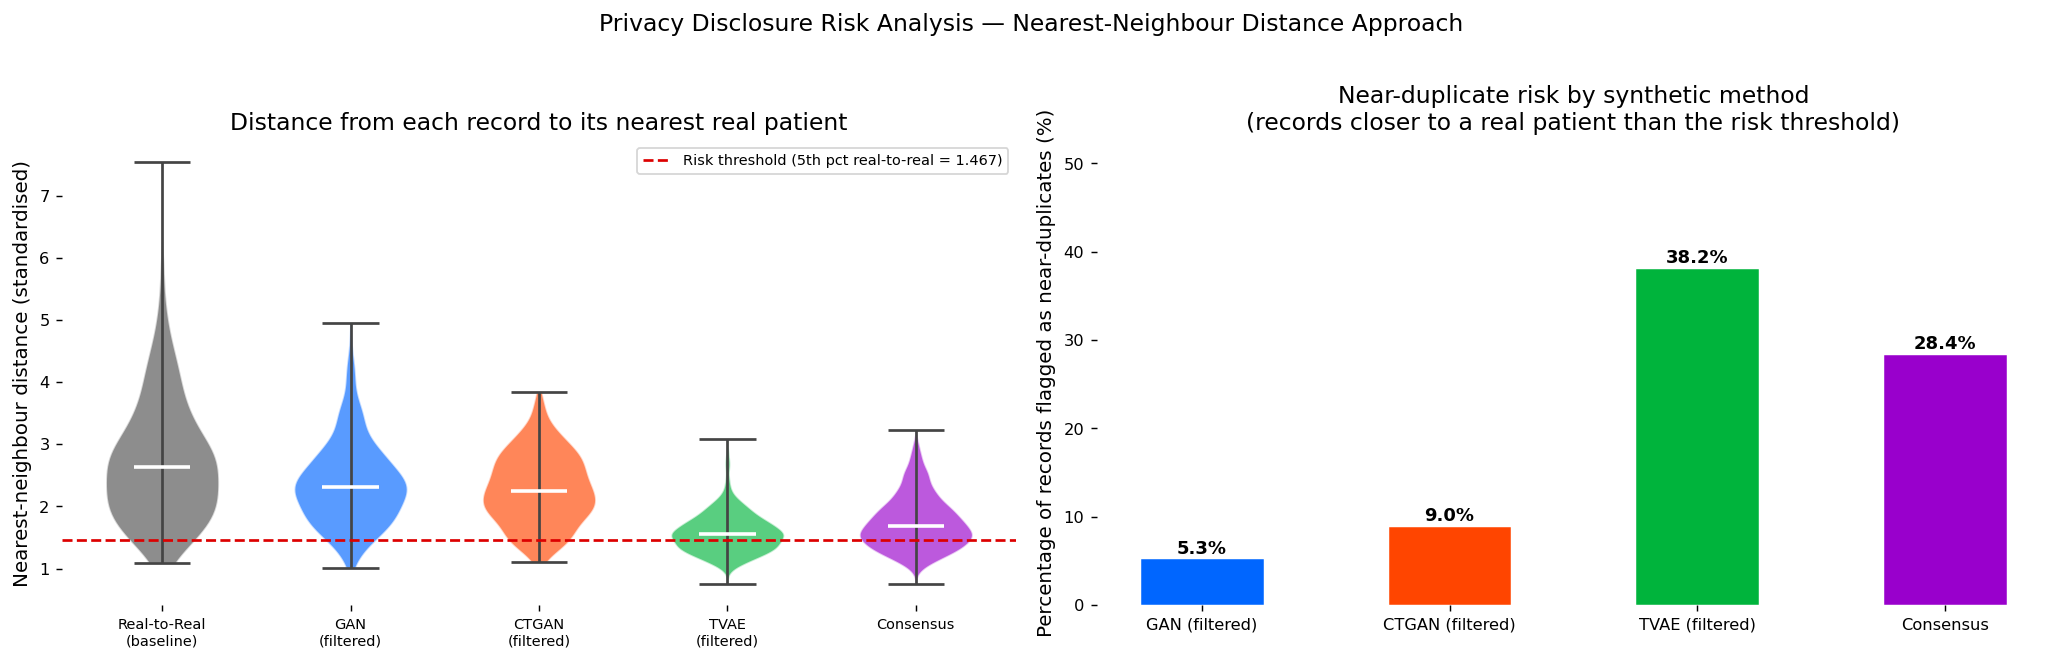

Figure saved.
Privacy summary saved to output/results/privacy_risk_summary.csv


In [23]:
# Plot the distribution of nearest-neighbour distances
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left panel — violin plot comparing distance distributions across methods
ax = axes[0]
plot_data  = [real_real_min] + [all_synth_dists[m] for m, _, _ in synth_datasets]
plot_labels = ['Real-to-Real\n(baseline)'] + [m.replace(' ', '\n') for m, _, _ in synth_datasets]
plot_colors = ['#505050'] + [c for _, _, c in synth_datasets]

parts = ax.violinplot(plot_data, positions=range(len(plot_data)),
                      showmedians=True, showextrema=True, widths=0.6)
for pc, color in zip(parts['bodies'], plot_colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.65)
    pc.set_edgecolor('white')
parts['cmedians'].set_color('white')
parts['cmedians'].set_linewidth(2)
for part in ['cbars', 'cmaxes', 'cmins']:
    parts[part].set_color('#444444')

ax.set_xticks(range(len(plot_labels)))
ax.set_xticklabels(plot_labels, fontsize=8)
ax.set_ylabel('Nearest-neighbour distance (standardised)')
ax.set_title('Distance from each record to its nearest real patient')

# Add the privacy threshold line
threshold = np.percentile(real_real_min, 5)
ax.axhline(threshold, color='#DC0000', linewidth=1.5, linestyle='--',
           label=f'Risk threshold (5th pct real-to-real = {threshold:.3f})')
ax.legend(fontsize=8)

# Right panel — bar chart of near-duplicate percentages
ax2 = axes[1]
methods = privacy_df['Method'].tolist()
risks   = privacy_df['Near-duplicate (%)'].tolist()
colors  = [c for _, _, c in synth_datasets]
bars = ax2.bar(methods, risks, color=colors, edgecolor='white', linewidth=0.8, width=0.5)
for bar, val in zip(bars, risks):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylabel('Percentage of records flagged as near-duplicates (%)')
ax2.set_title('Near-duplicate risk by synthetic method\n(records closer to a real patient than the risk threshold)')
ax2.set_ylim(0, max(risks) * 1.35 + 1)

plt.suptitle('Privacy Disclosure Risk Analysis — Nearest-Neighbour Distance Approach', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('output/figures/privacy_risk_analysis.png')
plt.show()
print('Figure saved.')
privacy_df.to_csv('output/results/privacy_risk_summary.csv', index=False)
print('Privacy summary saved to output/results/privacy_risk_summary.csv')